In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.0 MB/s eta 0:00:00


In [ ]:
!pip install lz4

In [ ]:
import cv2 as cv
import os
import tensorflow as ts
import numpy as np
import matplotlib.pyplot as plt
os.environ["TF_CPP_MIN_LOG_LEVEL"]="2"

In [ ]:
img=cv.imread("/content/drive/MyDrive/Dataset/Prakash/Copy of WhatsApp Image 2026-01-02 at 10.23.44 AM.jpeg")

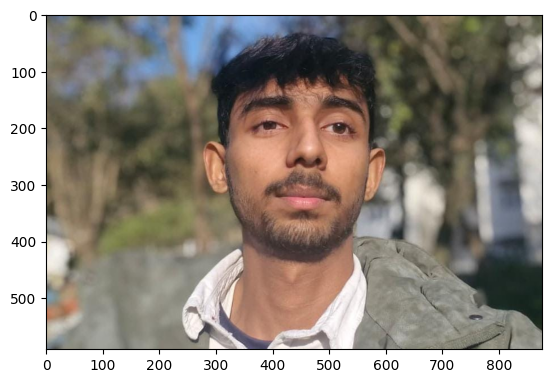

In [ ]:
img=cv.cvtColor(img,cv.COLOR_BGR2RGB)
plt.imshow(img)

In [ ]:
from mtcnn import MTCNN
detector=MTCNN()
results=detector.detect_faces(img)

In [ ]:
results

[{'box': [314, 69, 266, 338],
  'confidence': np.float64(0.9999978542327881),
  'keypoints': {'nose': [np.int64(460), np.int64(246)],
   'mouth_right': [np.int64(506), np.int64(326)],
   'right_eye': [np.int64(516), np.int64(197)],
   'left_eye': [np.int64(394), np.int64(191)],
   'mouth_left': [np.int64(399), np.int64(318)]}}]

In [ ]:
x,y,w,z=results[0]["box"]

In [ ]:
img=cv.rectangle(img,(x,y),(x+w,y+z),(0,255,0),2)

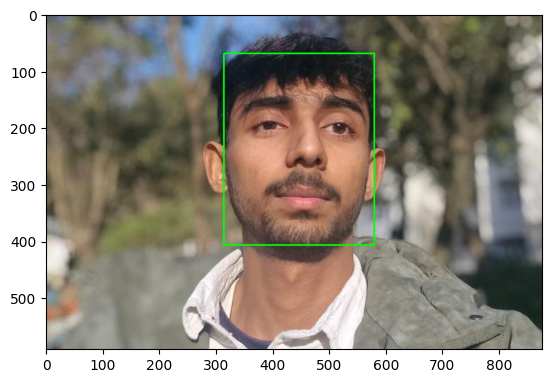

In [ ]:
plt.imshow(img)

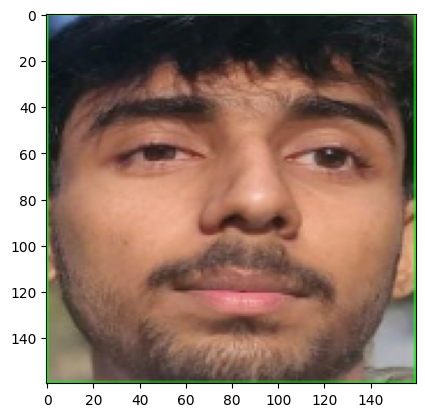

In [ ]:
my_face=img[y:y+z,x:x+w]
my_face=cv.resize(my_face,(160,160))
plt.imshow(my_face)

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [ 64,  92, 133],
        [ 73, 101, 144],
        ...,
        [ 78,  80,  69],
        [ 86,  87,  73],
        [ 30, 200,  25]],

       [[  0, 255,   0],
        [ 63,  92, 133],
        [ 73, 100, 143],
        ...,
        [ 72,  74,  65],
        [ 81,  81,  69],
        [ 28, 198,  24]],

       ...,

       [[  0, 255,   0],
        [144, 138, 117],
        [145, 137, 118],
        ...,
        [130, 124, 111],
        [125, 122, 107],
        [ 41, 211,  35]],

       [[  0, 255,   0],
        [144, 139, 118],
        [144, 137, 118],
        ...,
        [140, 134, 121],
        [130, 127, 112],
        [ 42, 211,  36]],

       [[  0, 255,   0],
        [ 80, 190,  66],
        [ 80, 189,  66],
        ...,
        [ 80, 190,  70],
        [ 76, 188,  66],
        [ 24, 232,  21]]], dtype=uint8)
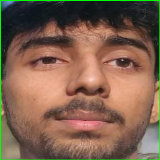

In [ ]:
my_face

In [ ]:
import joblib

# Save the label encoder to a file
# joblib.dump(encoder, 'label_encoder.pkl') # Commented out as encoder is defined and saved later

In [ ]:
class FACELOADING:
    def __init__(self, directory):
        self.directory = directory
        self.target_size = (160,160)
        self.X = []
        self.Y = []
        self.detector = MTCNN()


    def extract_face(self, filename):
        img = cv.imread(filename)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        x,y,w,h = self.detector.detect_faces(img)[0]['box']
        x,y = abs(x), abs(y)
        face = img[y:y+h, x:x+w]
        face_arr = cv.resize(face, self.target_size)
        return face_arr


    def load_faces(self, dir):
        FACES = []
        for im_name in os.listdir(dir):
            try:
                path = dir + im_name
                single_face = self.extract_face(path)
                FACES.append(single_face)
            except Exception as e:
                pass
        return FACES

    def load_classes(self):
        for sub_dir in os.listdir(self.directory):
            path = self.directory +'/'+ sub_dir+'/'
            FACES = self.load_faces(path)
            labels = [sub_dir for _ in range(len(FACES))]
            print(f"Loaded successfully: {len(labels)}")
            self.X.extend(FACES)
            self.Y.extend(labels)

        return np.asarray(self.X), np.asarray(self.Y)


    def plot_images(self):
        plt.figure(figsize=(18,16))
        for num,image in enumerate(self.X):
            ncols = 3
            nrows = len(self.Y)//ncols + 1
            plt.subplot(nrows,ncols,num+1)
            plt.imshow(image)
            plt.axis('off')

In [ ]:
faceloading=FACELOADING("/content/drive/MyDrive/Dataset")
X,Y=faceloading.load_classes()

Loaded successfully: 24
Loaded successfully: 24
Loaded successfully: 23
Loaded successfully: 19


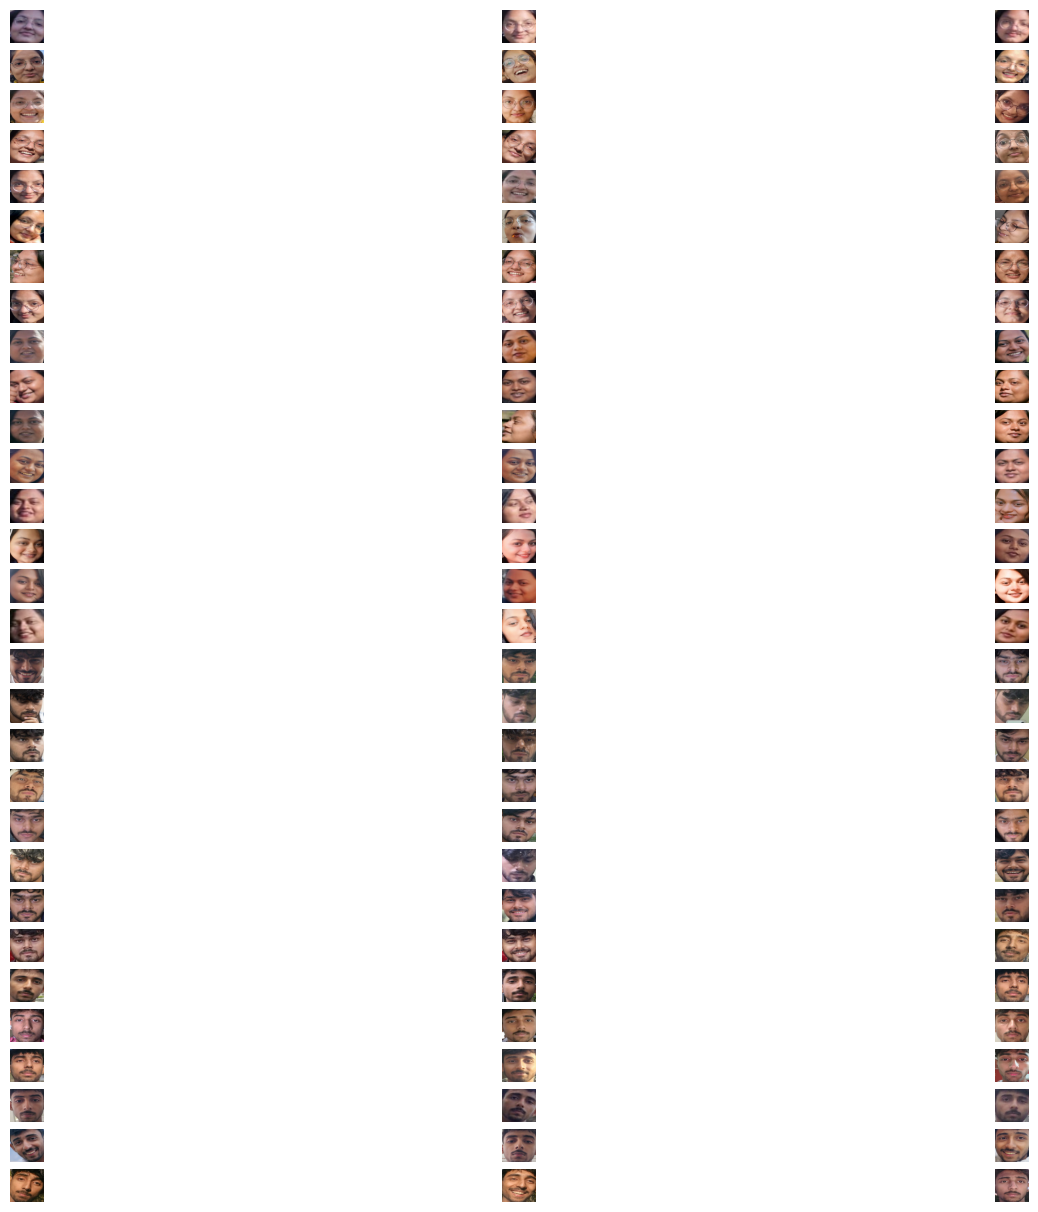

In [ ]:
faceloading.plot_images()

FACE_NET


In [ ]:
!pip install keras-facenet

  Preparing metadata (setup.py) ... done
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=d3dc8af8468170197c5c48fb23775acae4c43b01aedd893cc237cdb6651295aa
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras-facenet


In [ ]:
from keras_facenet import FaceNet
embedder = FaceNet()

def get_embedding(face_img):
    face_img = face_img.astype('float32') # 3D(160x160x3)
    face_img = np.expand_dims(face_img, axis=0)
    # 4D (Nonex160x160x3)
    yhat= embedder.embeddings(face_img)
    return yhat[0] # 512D image (1x1x512)

In [ ]:
EMBEDDED_X = []

for img in X:
    EMBEDDED_X.append(get_embedding(img))

EMBEDDED_X = np.asarray(EMBEDDED_X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
np.savez_compressed('faces_embeddings_done_4classes.npz', EMBEDDED_X, Y)

SVM Model

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(Y)
Y = encoder.transform(Y)

Text(0, 0.5, '1')

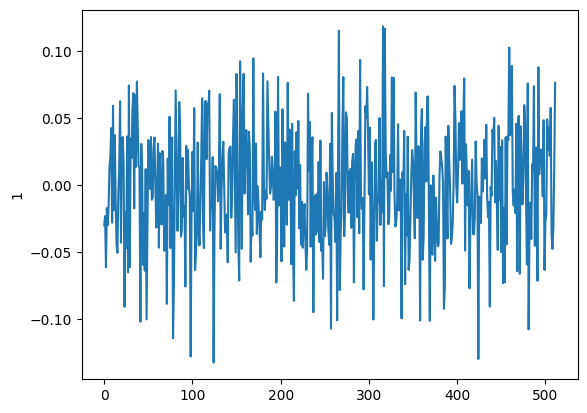

In [ ]:
plt.plot(EMBEDDED_X[0])
plt.ylabel(Y[0])

In [ ]:
Y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(EMBEDDED_X, Y, shuffle=True, random_state=17)

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='rbf', probability=True)
model.fit(X_train, Y_train)

SVC(probability=True)

In [ ]:
import joblib
from google.colab import files

# 1. Save the Label Encoder object
# In your code, 'encoder' is the variable used to fit the labels [cite: 264]
joblib.dump(encoder, 'label_encoder.pkl')

# 2. Save the SVM Model as well (to ensure versions match)
joblib.dump(model, 'face_recognition_model.pkl')

# 3. Trigger the browser download to your Mac
files.download('label_encoder.pkl')
files.download('face_recognition_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ypreds_train = model.predict(X_train)
ypreds_test = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(Y_train, ypreds_train)

1.0

In [ ]:
accuracy_score(Y_test,ypreds_test)

1.0

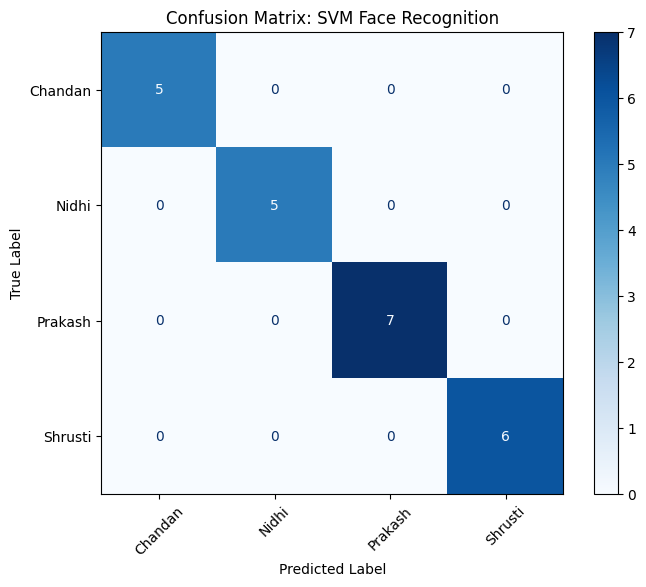

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plot the confusion matrix with display_labels
disp = ConfusionMatrixDisplay.from_predictions(
    Y_test,
    ypreds_test,
    display_labels=encoder.classes_,  # This tells the plot to use the original names
    cmap=plt.cm.Blues,
    ax=ax,
    colorbar=True
)

# 3. Add titles and labels
plt.title("Confusion Matrix: SVM Face Recognition")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45) # Optional: rotates names if they overlap
plt.show()